# 03 — Linear models: OLS, Ridge (L2) and Lasso (L1)
**EM 630 · Electricity Demand Forecasting · Phase 4**

**Question.** How far can a *linear* model go, and what does regularisation actually do on this data?

**What we already know**
- EDA: load features are strongly collinear (VIF up to 174, Fig 9); the daily shape **changes with season** (Fig 3); weather has no effect beyond the calendar (Fig 5).
- Baselines: the bar to beat is **74.3 MW** (persistence + average hourly step, Phase 3).

**Expectations written down before running (we check each one at the end)**
1. Ridge ≈ OLS in accuracy but with more stable coefficients.
2. Lasso sets the weather coefficients to zero.
3. The 47-feature linear model can't bend its daily shape by season, so it will struggle against the bar; adding **hour × month interactions** should fix that.

In [1]:
import sys, inspect, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
from src import config, data, features, split, linear_models as lm
pd.set_option("display.precision", 3)
def show(name, width=950):
    display(Image(filename=str(config.FIG_DIR / f"{name}.png"), width=width))

sp = split.chronological_split(features.build_features(data.load_clean()))
T = config.TARGET
X_dev = features.linear_design(sp.dev, False)
print("Base design:", X_dev.shape, "| with hour×month:", features.linear_design(sp.dev, True).shape)

Base design: (19047, 47) | with hour×month: (19047, 309)


---
## 1. Theory in one table

| | Objective | Solution | Convex? | Effect |
|---|---|---|---|---|
| **OLS** | $\min_\beta \|y-X\beta\|_2^2$ | $\hat\beta=(X^\top X)^{-1}X^\top y$ | yes | unbiased; high variance if $X^\top X$ is near-singular |
| **Ridge** | $\min_\beta \|y-X\beta\|_2^2+\alpha\|\beta\|_2^2$ | $\hat\beta=(X^\top X+\alpha I)^{-1}X^\top y$ | **strictly** (unique solution) | shrinks all coefficients smoothly; stabilises collinear ones |
| **Lasso** | $\min_\beta \frac1{2n}\|y-X\beta\|_2^2+\alpha\|\beta\|_1$ | no closed form → **coordinate descent** | yes | shrinks *and* sets some coefficients exactly to 0 (feature selection) |

**Why standardise first?** The penalty $\|\beta\|$ treats every coefficient equally. If one feature is in MW (thousands) and another is a 0/1 flag, the penalty would hit them unequally. `StandardScaler` puts all features on a common scale, and it sits **inside** the pipeline, so its mean and std come from the training rows only.

In [2]:
print(inspect.getsource(lm.pipe)); print(inspect.getsource(lm.make_model))

def pipe(model) -> Pipeline:
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

def make_model(kind: str, alpha: float | None = None):
    if kind == "ols":
        return LinearRegression()
    if kind == "ridge":
        return Ridge(alpha=alpha)
    if kind == "lasso":
        return Lasso(alpha=alpha, max_iter=20000, tol=1e-4)
    raise ValueError(kind)



**Checking the theory against the code.** Our tests verify that sklearn's OLS and Ridge coefficients equal the closed-form formulas above to 6 decimal places:

In [3]:
X = features.linear_design(sp.train, False).astype(float).values
Xs = (X - X.mean(0)) / X.std(0); y = sp.train[T].values; yc = y - y.mean()
for kind, a in [("ols", None), ("ridge", 50.0)]:
    m = lm.fit_final(features.linear_design(sp.train, False), sp.train[T], kind, a)
    A = Xs.T @ Xs + (0 if a is None else a) * np.eye(Xs.shape[1])
    b = np.linalg.solve(A, Xs.T @ yc)
    print(f"{kind:5s}: max |sklearn − closed form| = {np.abs(m.named_steps['model'].coef_ - b).max():.2e}")

ols  : max |sklearn − closed form| = 6.12e-11
ridge: max |sklearn − closed form| = 7.55e-11


---
## 2. Choosing α with time-series cross-validation

💡 **Hyperparameter tuning without leakage.** α isn't learned by the optimiser; we pick it by **forward-chaining CV**. Each fold trains on the past and validates on the block right after it, never the other way round:

```
fold 1: [train]               [val]
fold 2: [train......]               [val]
...
fold 5: [train...........................]  [val]
```
Two rules are reported:
- **best α**: lowest mean CV error;
- **1-SE α**: the *most regularised* α whose error is within one standard error of the best, the simplest model that is statistically tied.

In [4]:
print(inspect.getsource(lm.cv_curve)); print(inspect.getsource(lm.select_alpha))

def cv_curve(X: pd.DataFrame, y: pd.Series, kind: str, alphas, n_splits: int = N_SPLITS) -> pd.DataFrame:
    """Forward-chaining CV: fold k trains on everything before its validation block.
    Returns one row per (alpha, fold) with validation MSE and MAE."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, va) in enumerate(tscv.split(X)):
        m = pipe(make_model(kind, alphas[0]))
        if kind == "lasso":                       # large -> small alpha, warm-started (same optimum, faster)
            m.set_params(model__warm_start=True)
            alphas = sorted(alphas, reverse=True)
        for a in alphas:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                m.set_params(model__alpha=a).fit(X.iloc[tr], y.iloc[tr])
            p = m.predict(X.iloc[va])
            err = y.iloc[va].values - p
            rows.append({"alpha": a, "fold": fold, "mse": float(np.mean(err ** 2)),


In [5]:
pd.read_csv(config.TABLE_DIR / "phase4_alphas.csv")

,model,split,alpha_best,alpha_1se,n_features,best_at_low_edge,curve_flat_there,grid_min,grid_max
0,Ridge,val,6.510e-01,31.012,47,False,True,1.000e-04,100000.000
1,Lasso,val,7.023e-02,2.355,47,False,True,1.311e-03,1311.406
2,Ridge,test,2.759e-02,7.609,47,False,True,1.000e-04,100000.000
3,Lasso,test,1.307e-03,0.920,47,True,True,1.307e-03,1307.253
4,Ridge + hour×month,val,1.000e-04,21.826,309,True,True,1.000e-04,100000.000
5,Lasso + hour×month,val,4.397e-02,3.762,309,False,False,1.311e-03,1311.406
6,Ridge + hour×month,test,1.000e-04,10.812,309,True,True,1.000e-04,100000.000
7,Lasso + hour×month,test,2.171e-02,2.347,309,False,False,1.307e-03,1307.253


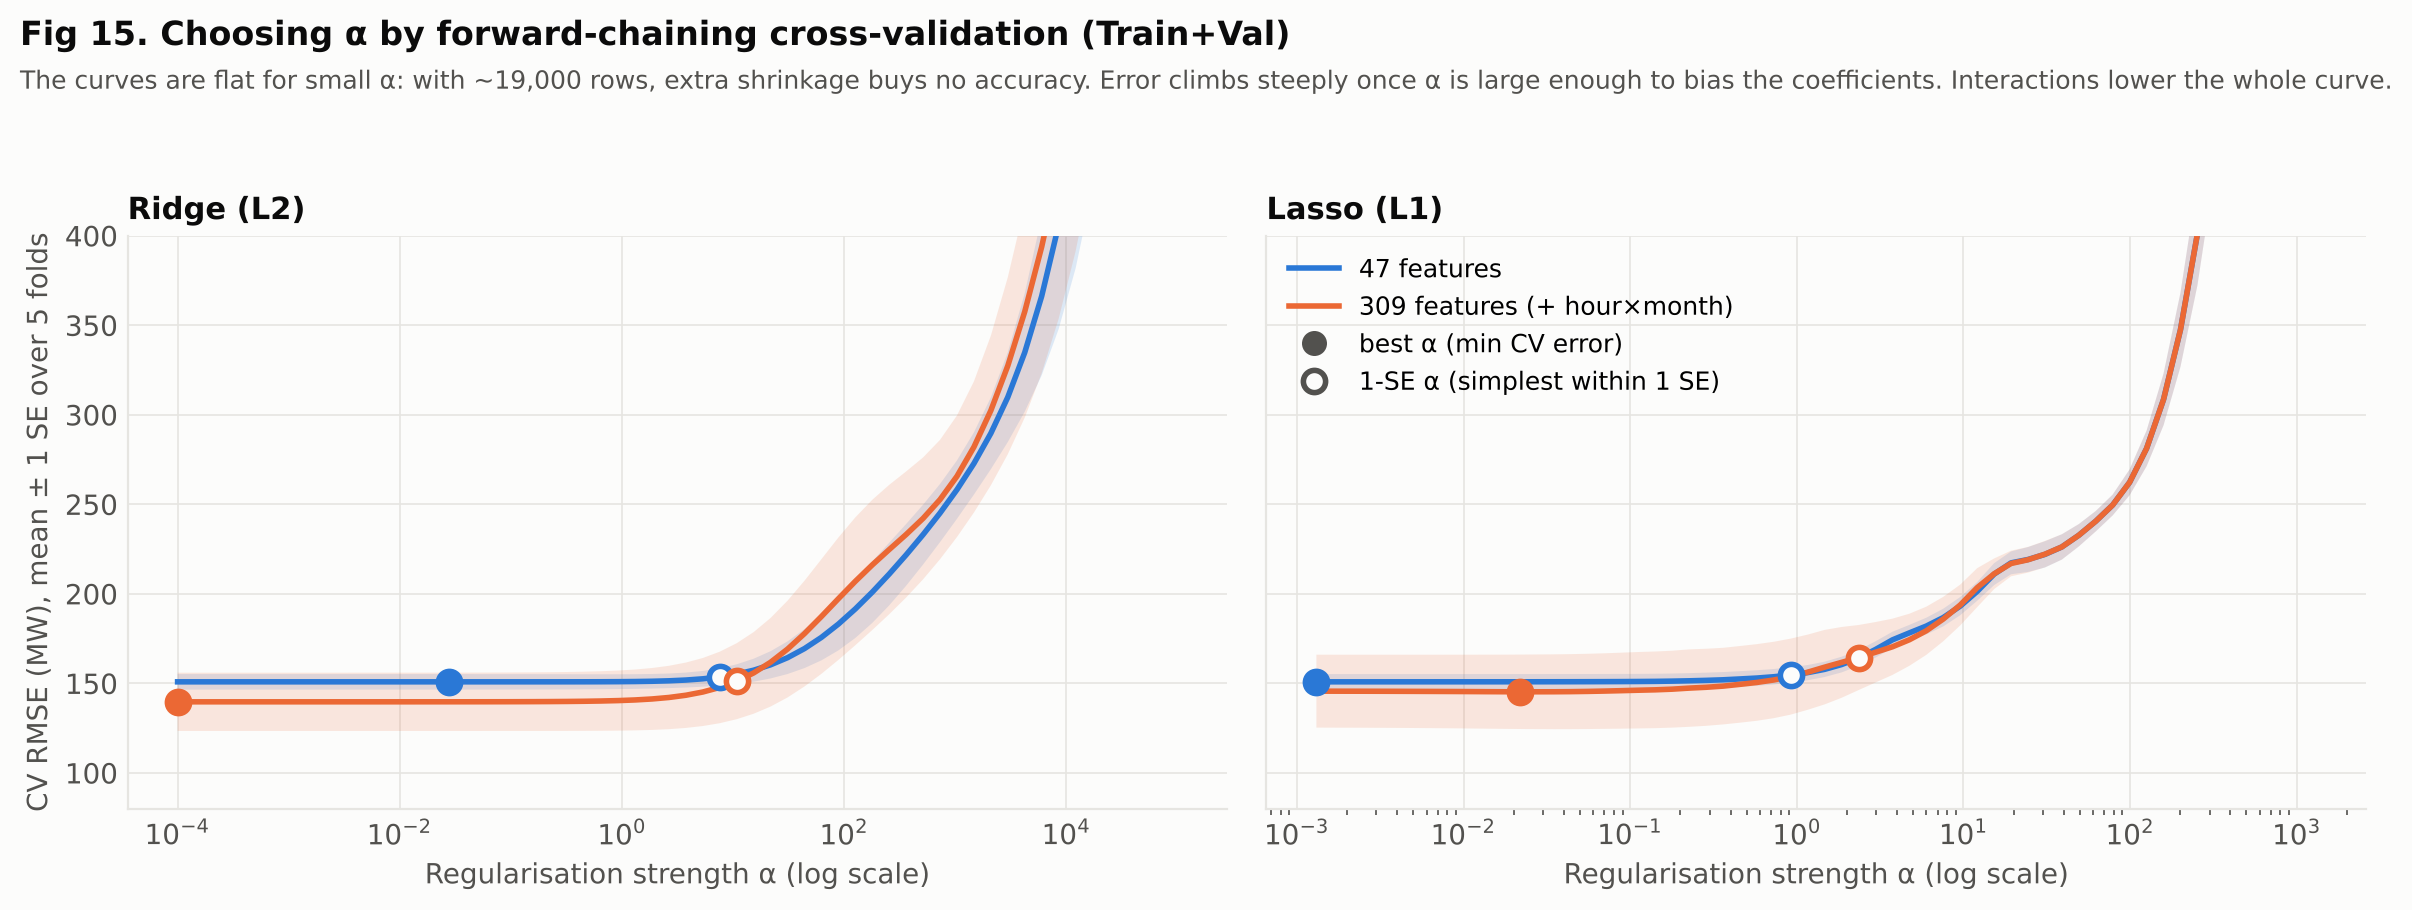

In [6]:
show("F15_cv_alpha_curves")

✅ **Finding.** The CV curves are **flat** for small α and only rise once α is large. For three models the "best" α is the smallest one tried, but the curve is flat there (the `curve_flat_there` column, also enforced by a test). The honest reading is that **regularisation does not improve accuracy here**.

💡 **Why? Sample size.** The variance of OLS shrinks like $\sigma^2/n$. With $n \approx 19{,}000$ rows and $p = 47$ (or 309) features, OLS variance is already small, so there is little left for shrinkage to remove, and any shrinkage adds bias. Regularisation pays off when $p$ is large relative to $n$. Section 4 shows this directly.

---
## 3. Lasso: sparsity and the order features enter

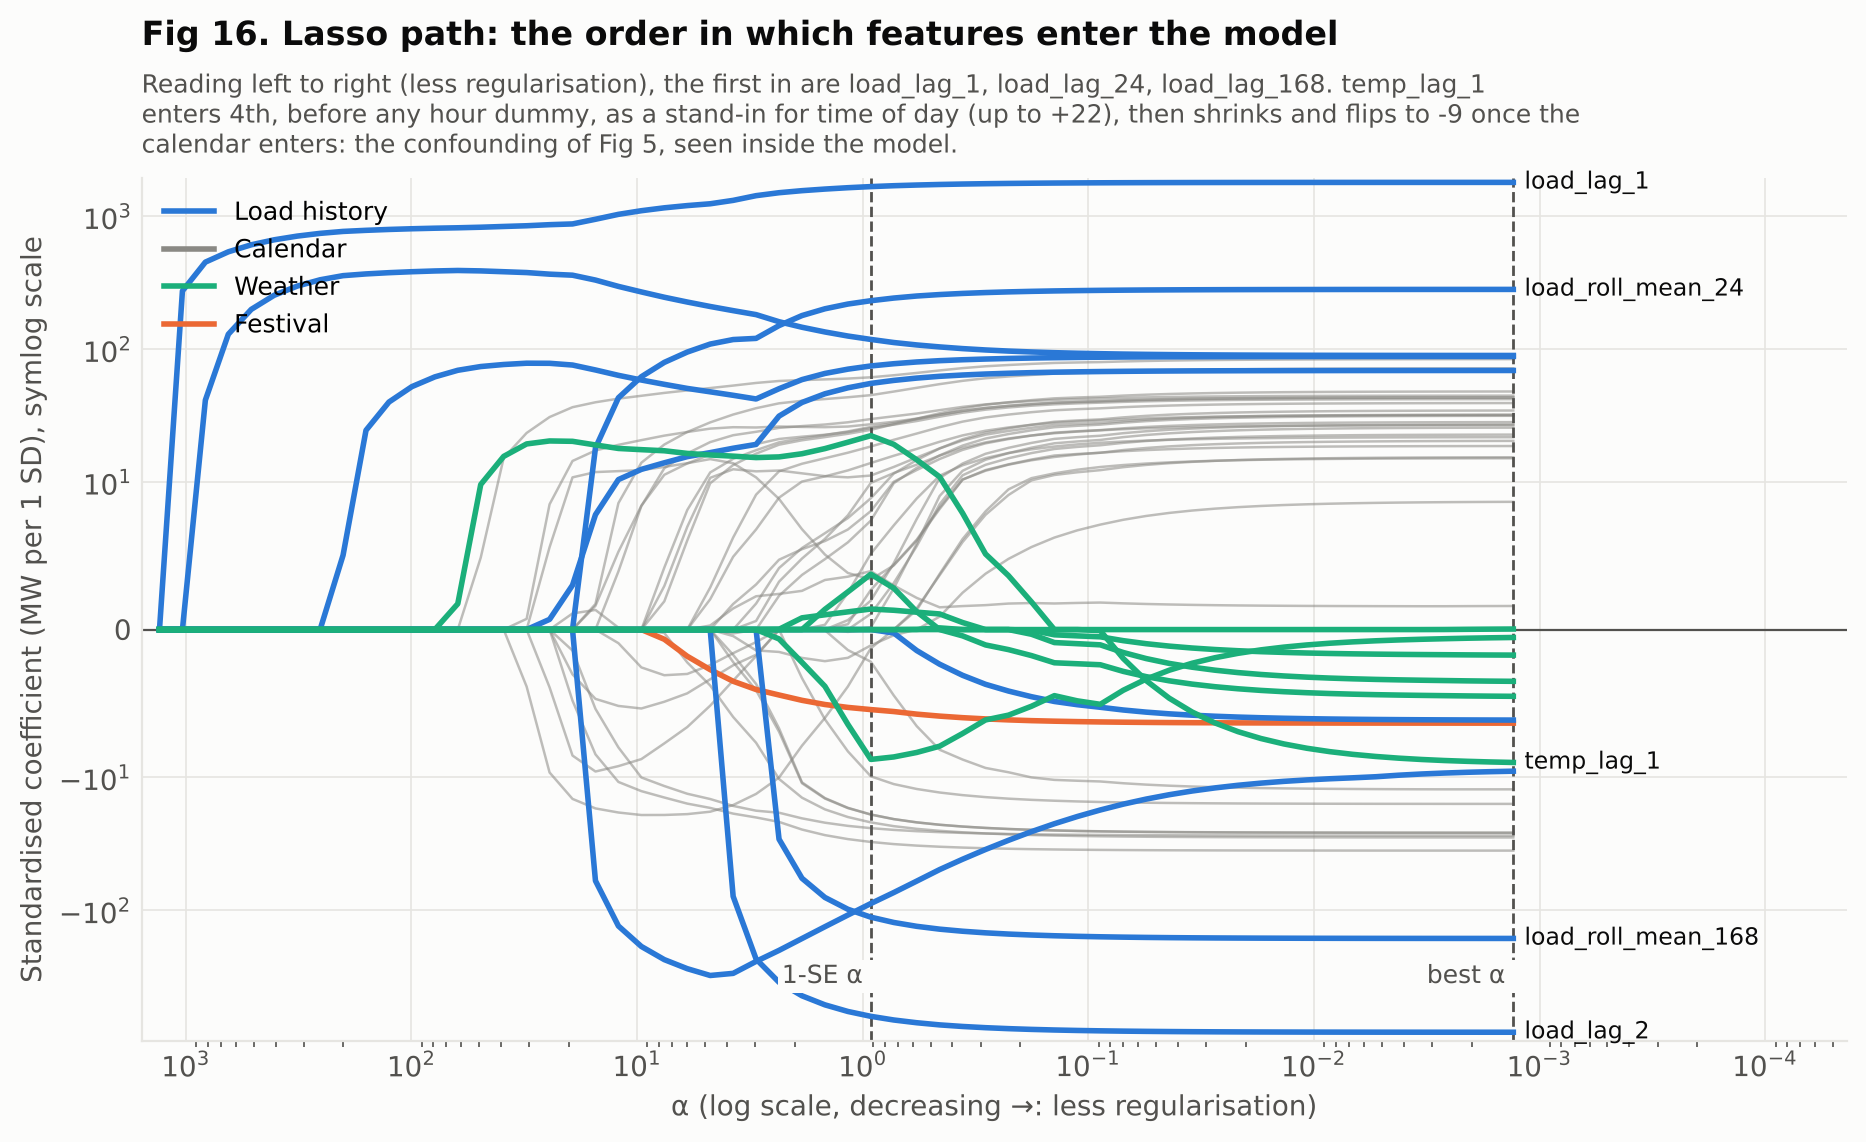

In [7]:
show("F16_lasso_path")

In [8]:
c = pd.read_csv(config.TABLE_DIR / "phase4_coefficients_std.csv", index_col=0)
rows = []
for m in ["Lasso", "Lasso (1-SE α)", "Lasso + hour×month", "Lasso + hour×month (1-SE α)"]:
    s = c[m].dropna(); nz = s.abs() > 1e-9
    rows.append({"model": m, "non-zero": f"{nz.sum()}/{len(s)}",
                 "weather kept": ", ".join(w for w in features.WEATHER if nz.get(w, False)) or "none"})
pd.DataFrame(rows)

,model,non-zero,weather kept
0,Lasso,47/47,"temp_lag_1, humidity_lag_1, temp_roll_mean_24,..."
1,Lasso (1-SE α),43/47,"temp_lag_1, humidity_lag_1, temp_roll_mean_24,..."
2,Lasso + hour×month,307/309,"temp_lag_1, humidity_lag_1, temp_roll_mean_24,..."
3,Lasso + hour×month (1-SE α),182/309,"temp_lag_1, weather_lag_1_rain"


In [9]:
c.loc[features.WEATHER, ["OLS", "Lasso", "Lasso (1-SE α)"]].round(2)

,OLS,Lasso,Lasso (1-SE α)
temp_lag_1,-9.13,-9.00,22.28
humidity_lag_1,0.07,0.04,3.75
temp_roll_mean_24,-0.45,-0.54,-8.80
weather_lag_1_cloudy,-1.76,-1.73,0.00
weather_lag_1_rain,-3.56,-3.50,1.39
weather_lag_1_storm,-4.56,-4.52,0.00


✅ **Findings**
- The first features in (largest α) are `load_lag_1`, `load_lag_24` and `load_lag_168`: persistence, then the daily cycle, then the weekly cycle, the same ranking as the ACF in EDA Fig 8.
- **Expectation 2 only partly holds.** At the CV-best α, Lasso keeps all 6 weather features, but they are tiny (≤ 9 MW per SD, against 1,791 for `load_lag_1`). At the 1-SE α it drops two of them, and `temp_lag_1` **flips sign** (−9 → +22). An unstable sign is itself a sign of no real signal.
- **Confounding, seen inside the model:** `temp_lag_1` enters 4th, before any hour dummy, acting as a stand-in for time of day. When the hour dummies enter it shrinks and flips. That is exactly the EDA finding (Fig 5), that temperature only looked useful because it tracks the clock.
- `load_lag_1` and `load_lag_2` carry large **opposite-signed** coefficients (+1,791 / −828). That is the collinearity signature: together they encode "level + momentum".

---
## 4. The bias–variance trade-off, measured

A first attempt compared coefficient spread across the 5 CV folds and found Ridge *less* stable than OLS. The evaluator rejected that test. CV folds have **growing** sizes, and a fixed α penalises small samples more, so the spread mixed shrinkage differences with variance. The fair test fits on **equal-size 30-day windows**:

In [10]:
print(inspect.getsource(lm.window_bias_variance))
pd.read_csv(config.TABLE_DIR / "phase4_bias_variance.csv")

def window_bias_variance(X, y, alphas, cols, days: int = 30) -> pd.DataFrame:
    """Fair stability test: fit on consecutive EQUAL-SIZE windows of `days` days and forecast the
    next window. For each alpha (0 = OLS):
      coef_spread = sum over `cols` of the std of the standardised coefficient across windows (variance)
      next_mae    = mean MAE on the following window (what the variance/bias mix costs in accuracy)
    Equal sizes matter: with expanding windows a fixed alpha shrinks small windows more, which would
    confound shrinkage with variance."""
    n = days * 24
    k = len(X) // n
    idx = [X.columns.get_loc(c) for c in cols]
    rows = []
    for a in alphas:
        kind = "ols" if a == 0 else "ridge"
        co, err = [], []
        for i in range(k - 1):
            tr, te = slice(i * n, (i + 1) * n), slice((i + 1) * n, min((i + 2) * n, len(X)))
            m = fit_final(X.iloc[tr], y.iloc[tr], kind, None if a == 0 else a)
            co.append(m.named_steps["model

,alpha,coef_spread,next_window_mae,windows,window_days
0,0.0,632.477,102.121,25,30
1,0.1,618.739,102.468,25,30
2,0.3,596.210,103.190,25,30
3,1.0,547.451,105.785,25,30
4,3.0,494.396,112.154,25,30
5,10.0,444.894,125.596,25,30
6,30.0,409.040,141.686,25,30
7,100.0,351.125,161.106,25,30


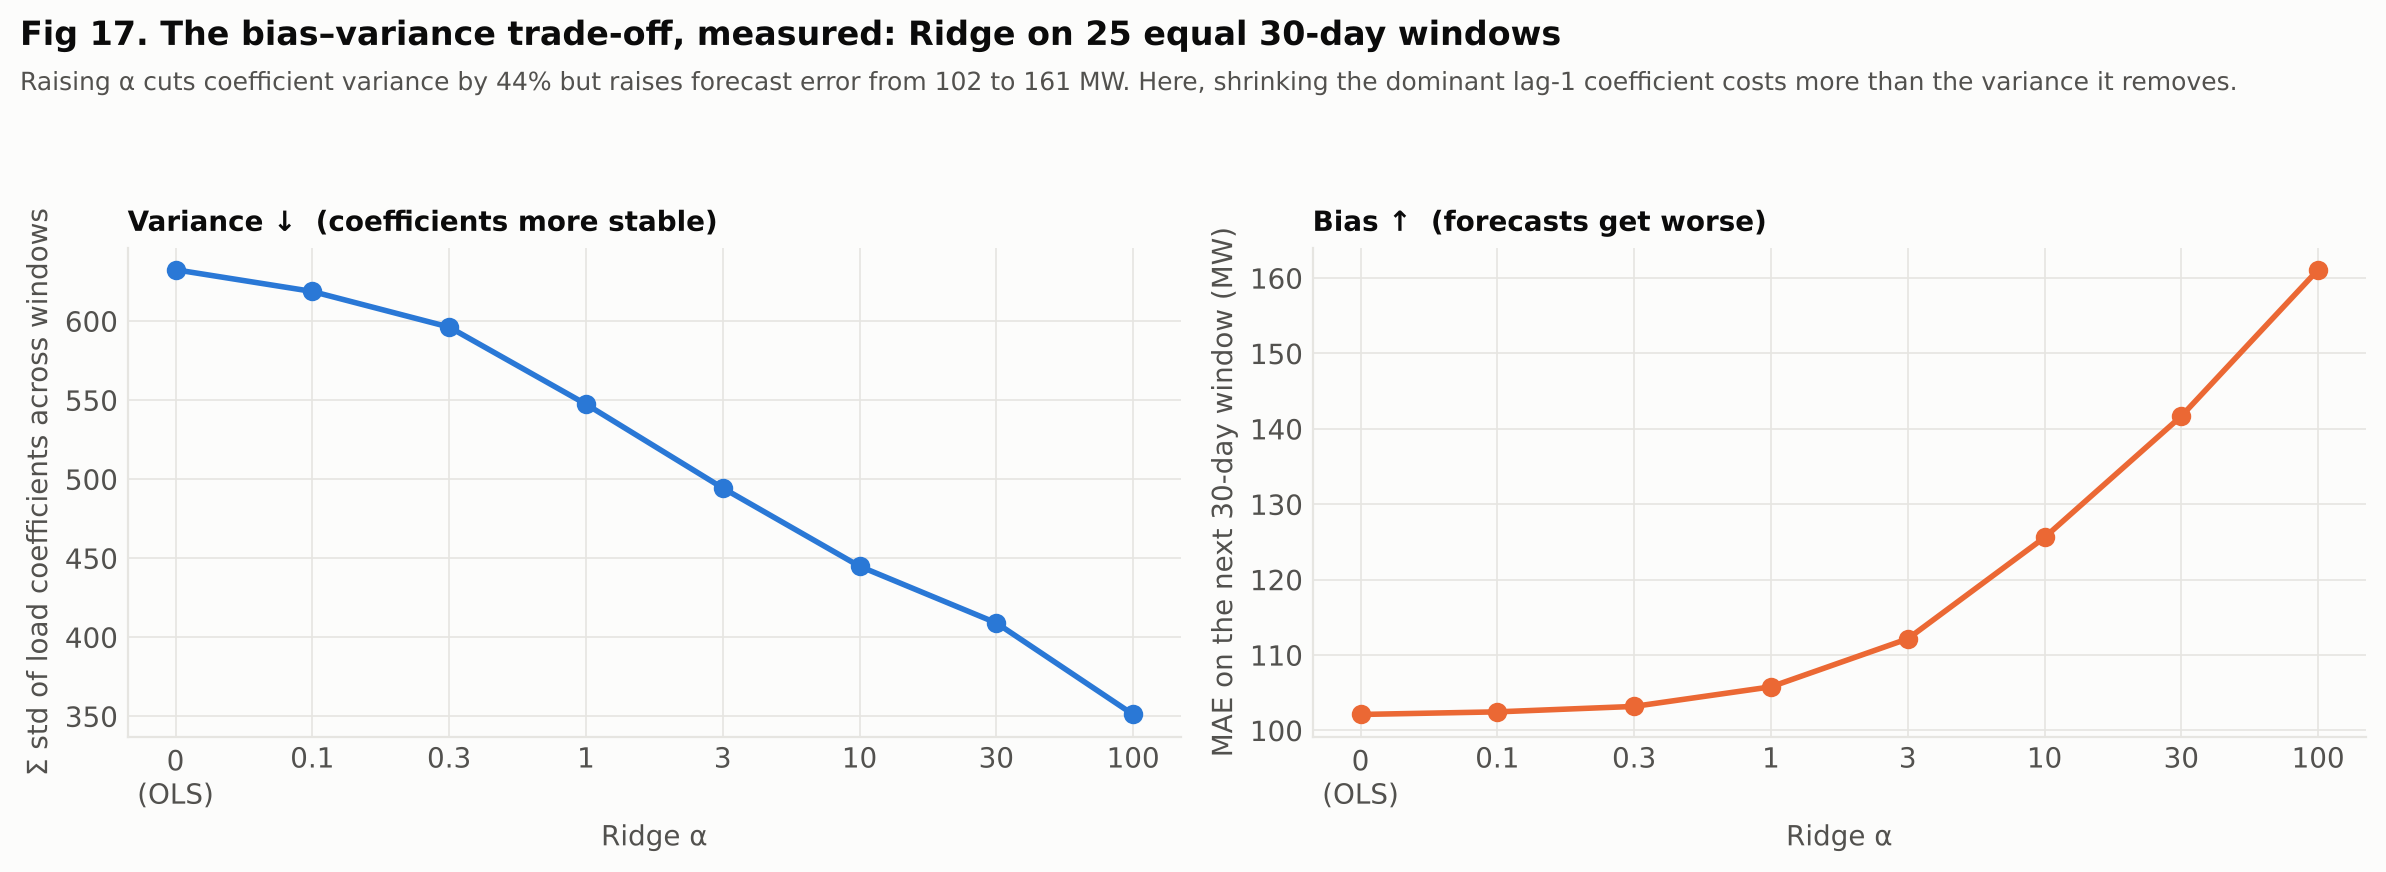

In [11]:
show("F17_bias_variance")

✅ **Finding: the textbook trade-off, in numbers.** As α grows, **variance falls** (coefficient spread down 44%) while **bias rises** (next-window MAE from 102 to 161 MW). On this data the bias wins: the true model needs a large `load_lag_1` weight, and shrinking it toward zero hurts.
**Expectation 1:** ✔ for stability, ✔ "Ridge ≈ OLS" at CV-best α (tied within 0.01 MW), ✘ if we had hoped Ridge would be *more accurate*.

---
## 5. Results on the test set

In [12]:
tab = pd.read_csv(config.TABLE_DIR / "phase4_linear.csv")
cols = ["model", "MAE", "RMSE", "MAPE", "R2", "Bias", "skill_vs_naive1", "skill_vs_step"]
tab[(tab.split == "test") & (tab.subset == "all")][cols].sort_values("MAE").reset_index(drop=True)

,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1,skill_vs_step
0,Lasso + hour×month,64.913,92.030,1.558,0.995,5.077,0.683,0.127
1,OLS + hour×month,65.259,92.810,1.571,0.995,4.906,0.681,0.122
2,Ridge + hour×month,65.259,92.810,1.571,0.995,4.906,0.681,0.122
3,Ridge + hour×month (1-SE α),65.895,93.368,1.564,0.995,5.596,0.678,0.113
4,Naive-1 + hourly step,74.313,104.284,1.774,0.994,2.158,0.637,0.000
5,Lasso + hour×month (1-SE α),79.298,109.150,1.862,0.993,1.181,0.613,-0.067
6,Lasso,92.357,122.937,2.164,0.991,4.441,0.549,-0.243
7,OLS,92.362,122.941,2.164,0.991,4.445,0.549,-0.243
8,Ridge,92.366,122.947,2.164,0.991,4.445,0.549,-0.243
9,Lasso (1-SE α),92.518,124.402,2.167,0.991,2.900,0.548,-0.245


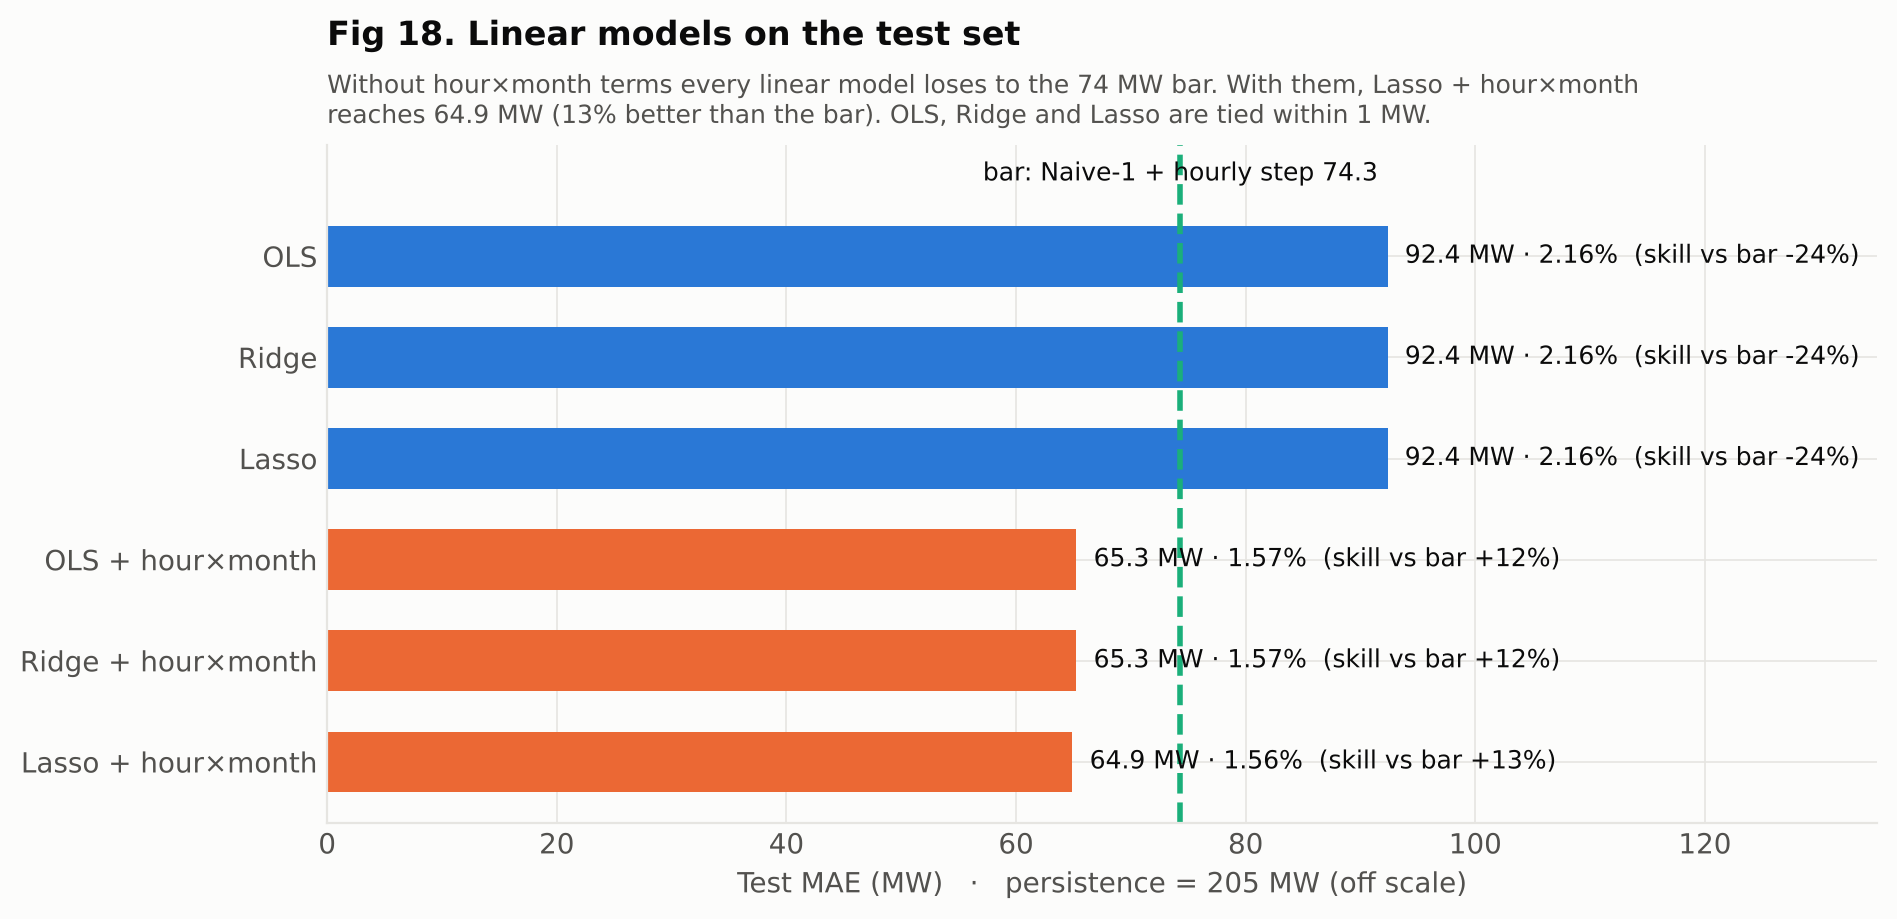

In [13]:
show("F18_linear_results")

✅ **Expectation 3 confirmed.** With 47 features, every linear model reaches only **92 MW**, worse than the 74 MW lookup table, because it applies the *same* hourly adjustment all year. Adding the hour×month interactions (309 features) brings it to **64.9 MW (Lasso), 13% better than the bar** and better than v1's tuned XGBoost (74.4 MW).

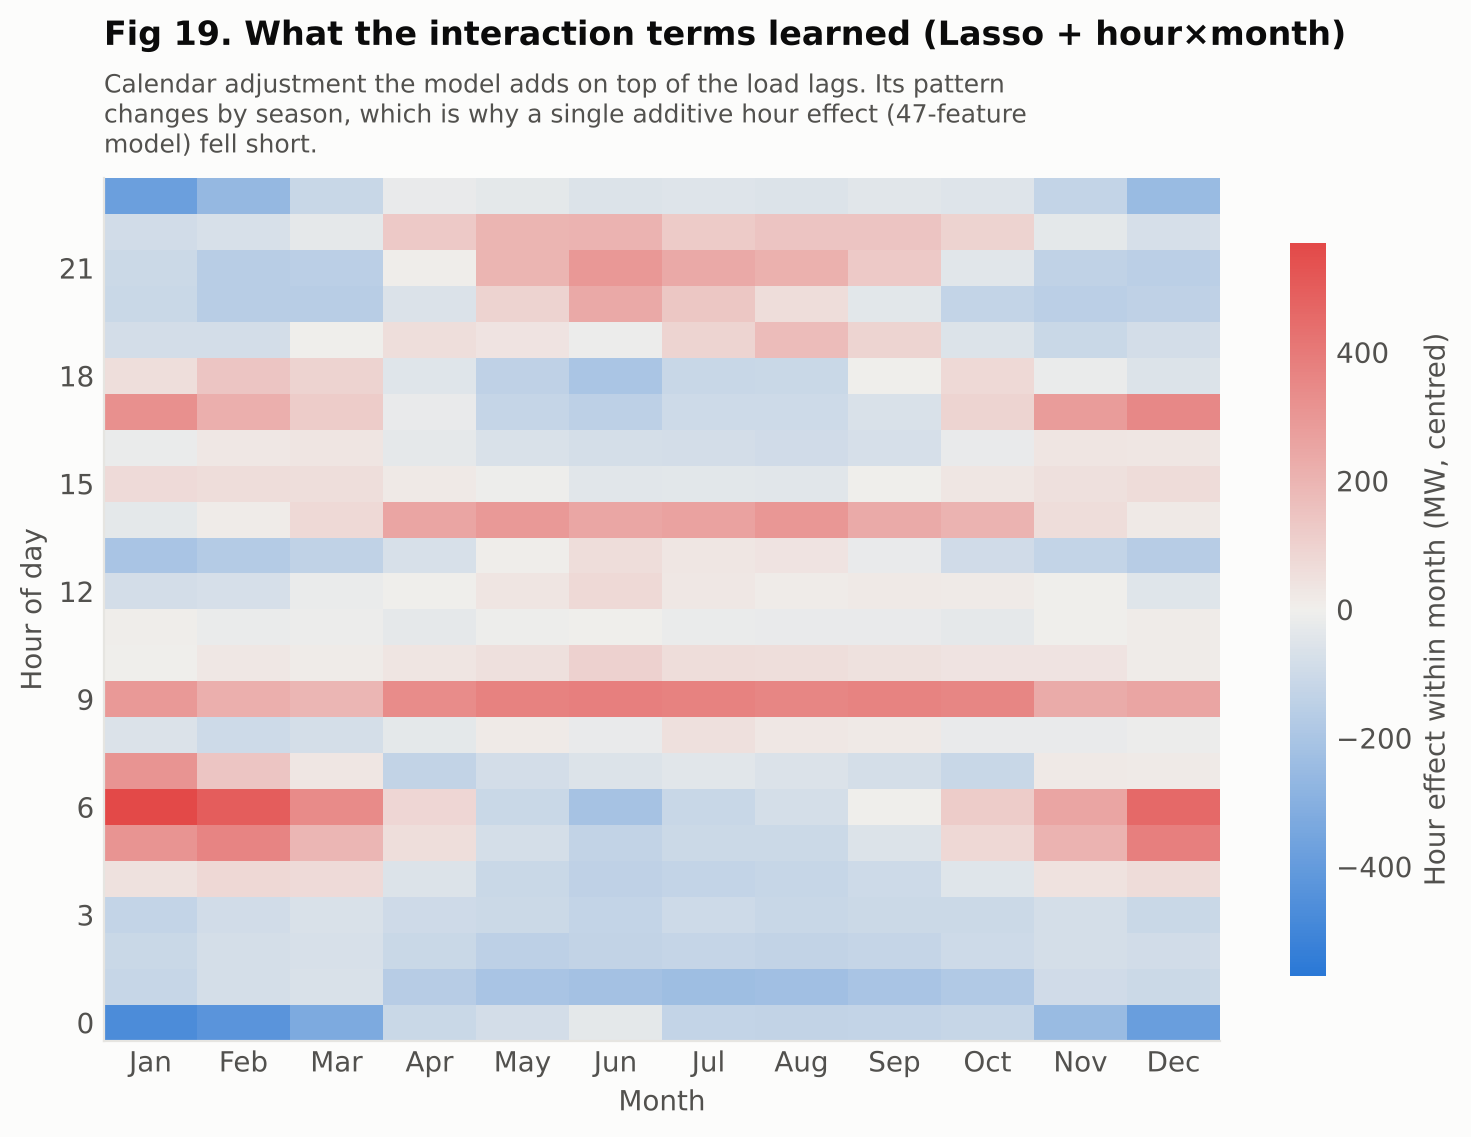

In [14]:
show("F19_learned_hour_month", 800)

💡 **What the interactions learned.** The 09:00 step (EDA, Phase 3) shows clearly in every month. The winter 05:00–06:00 bump and the summer late-evening block show that the hourly adjustment depends on the season, which a single additive hour effect can't represent.

### Peak hours

In [15]:
tab[(tab.split == "test") & (tab.subset == "peak")][["model", "n", "MAE", "MAPE", "Bias"]].sort_values("MAE").reset_index(drop=True)

,model,n,MAE,MAPE,Bias
0,Lasso + hour×month,588,62.664,0.955,24.643
1,OLS + hour×month,588,62.738,0.957,24.615
2,Ridge + hour×month,588,62.738,0.957,24.615
3,Ridge + hour×month (1-SE α),588,66.200,1.008,28.398
4,Naive-1 + hourly step,588,66.256,1.014,8.615
5,Lasso + hour×month (1-SE α),588,90.986,1.387,48.252
6,Lasso,588,104.077,1.587,44.796
7,OLS,588,104.084,1.587,44.790
8,Ridge,588,104.092,1.587,44.803
9,Lasso (1-SE α),588,104.805,1.597,51.956


---
## 6. Summary

| Expectation | Result |
|---|---|
| Ridge ≈ OLS in accuracy, more stable coefficients | ✔ tied at CV-best α; stability gain demonstrated on equal windows, but it costs accuracy (bias) |
| Lasso zeroes weather | ◐ only at the 1-SE α, and with a sign flip; at best α weather is kept but negligible |
| Linear needs hour×month to compete | ✔ 92.4 → 64.9 MW; beats the 74.3 MW bar by 13% |

**Takeaways for the report**
1. With $n \gg p$, regularisation isn't needed for **accuracy**; its value here is **interpretability** (Lasso path) and **stability**.
2. **Feature engineering beat algorithm choice:** adding the right interaction cut error by 30%, while switching OLS → Ridge → Lasso changed it by under 1%.
3. The best linear model (**64.9 MW**) is the new reference for Phases 5–6: XGBoost and the MLP must beat it to justify their extra complexity.